# 실습 4-2 : Under/Over Sampling (AI4I 데이터 버전)

#### **<실습 내용>**

1. 클래스 불균형 데이터 확인
- t-SNE를 통한 시각화

2. Resampling 기법 적용
- Random Undersampling
- TomekLinks (Undersampling)
- SMOTE (Oversampling)
- SMOTE + TomekLinks (복합 Resampling)
- ADASYN (Oversampling)

3. Resampling 전후 T-SNE 및 성능 비교

## 분석 준비

### 주요 라이브러리 호출

In [1]:
# 실행해서 설치해주세요.
! uv add imbalanced-learn

Resolved 386 packages in 30ms
Checked 351 packages in 57ms


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.manifold import TSNE

from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### 데이터 불러오기

In [3]:
data = pd.read_csv("dataset/day4-2_data.csv")

# 고장 유형 컬럼(TWF~RNF)은 Machine failure 여부와 직접 연관되어 정보 누수가 발생하므로 제거
data = data.drop(columns=["TWF", "HDF", "PWF", "OSF", "RNF"])

# Type(범주형)은 원-핫 인코딩
data = pd.get_dummies(data, columns=["Type"], drop_first=True)

print("데이터 크기:", data.shape)
print("결측치 수:", data.isnull().sum().sum())
data.head()

데이터 크기: (10000, 8)
결측치 수: 0


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


---

## 1) 클래스 불균형 확인

> **클래스 불균형(Class Imbalance)** 이란 정상 데이터의 양이 불량 데이터보다 훨씬 많은 상황을 의미함
> - 해결 기법: **Resampling** (Under/Over Sampling) 또는 **One-Class Learning Model**

In [4]:
X = data.drop(["Machine failure"], axis=1)  # 타겟 컬럼 제외한 나머지를 입력 변수로 사용
Y = data["Machine failure"]

In [5]:
print("클래스 분포:")
print(Y.value_counts())  # 클래스별 개수 확인

클래스 분포:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [6]:
print("클래스 비율:")
print(np.round(Y.value_counts(normalize=True), 3))  # 클래스별 비율 확인 (소수점 3자리)

클래스 비율:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


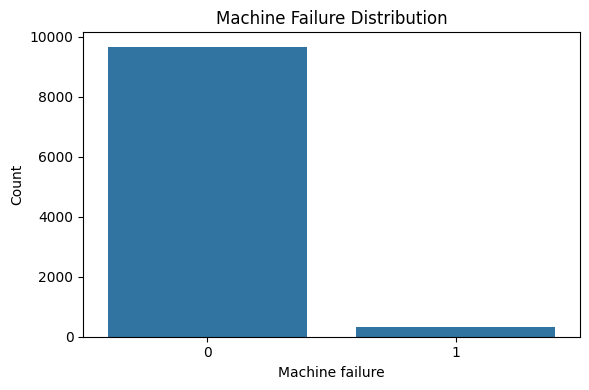

In [7]:
# 클래스 분포 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=Y.value_counts().index, y=Y.value_counts().values)  # 클래스별 개수를 막대그래프로 표시
plt.title("Machine Failure Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 1-1) t-SNE를 통한 시각화

> **t-SNE**는 고차원 데이터를 2차원으로 매핑하여 시각화하는 기법임
> - 클래스 간 분리 정도를 시각적으로 확인할 수 있음
> - 분리가 잘 될수록 분류 모델이 두 클래스를 구분하기 쉬운 데이터라는 뜻임

In [8]:
# n_components=2 : 원래 수백 개 특성을 가진 데이터를 2차원 좌표(x, y)로 압축
# fit_transform(X) : X를 학습하면서 동시에 2차원 좌표로 변환

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
X_embedded

array([[ 19.91204  , -60.95746  ],
       [-62.04556  , -55.303257 ],
       [ -6.0506363, -65.91889  ],
       ...,
       [ 53.168148 , -37.35995  ],
       [-53.897152 , -49.04397  ],
       [ -4.401443 , -56.462643 ]], shape=(10000, 2), dtype=float32)

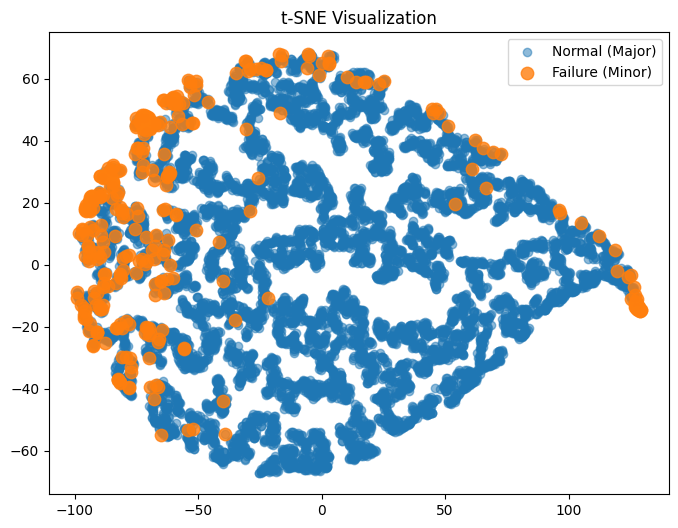

In [9]:
plt.figure(figsize=(8, 6))
# X_embedded[Y == 0, 0] : Normal 클래스(Y=0)의 x좌표, X_embedded[Y == 0, 1] : y좌표
plt.scatter(X_embedded[Y == 0, 0], X_embedded[Y == 0, 1], label='Normal (Major)', alpha=0.5)  # 다수 클래스(정상) 산점도
# X_embedded[Y == 1, 0] : Failure 클래스(Y=1)의 x좌표, X_embedded[Y == 1, 1] : y좌표
plt.scatter(X_embedded[Y == 1, 0], X_embedded[Y == 1, 1], label='Failure (Minor)', alpha=0.8, s=80)  # 소수 클래스(고장) 산점도, 점 크기 크게
plt.legend()
plt.title("t-SNE Visualization")
plt.show()

---

## 2) Resampling 기법 적용

| 기법 | 유형 | 설명 |
|---|---|---|
| TomekLinks | Undersampling | 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함 |
| SMOTE | Oversampling | 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄 |
| SMOTE + TomekLinks | 복합 Resampling | SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함 |
| ADASYN | Oversampling | SMOTE와 비슷하지만 구분이 어려운 샘플 주변에 더 많은 가상 샘플을 만들어냄 |

> Resampling은 **학습 데이터에만** 적용하고, 테스트 데이터는 원본 그대로 유지해야 함

In [10]:
# test는 실제 환경과 동일한 불균형 상태를 유지해야 모델 성능을 제대로 평가할 수 있음

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("학습 데이터 클래스 분포:")
print(Y_train.value_counts())

학습 데이터 클래스 분포:
Machine failure
0    7729
1     271
Name: count, dtype: int64


### 2-1) TomekLinks (Undersampling)

> **Tomek Links**는 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함

In [11]:
X_TomekLinks, Y_TomekLinks = TomekLinks().fit_resample(X_train, Y_train)  # TomekLinks로 다수 클래스 일부 제거 (undersampling)

# 적용 전/후 클래스별 개수 비교
compare_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_TomekLinks.value_counts()})
compare_TL["변화"] = compare_TL["적용 후"] - compare_TL["적용 전"]  # 클래스별 변화량 계산
compare_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7641,-88
1,271,271,0


### 2-2) SMOTE (Oversampling)

> **SMOTE**는 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄

In [12]:
X_SMOTE, Y_SMOTE = SMOTE().fit_resample(X_train, Y_train)  # SMOTE로 소수 클래스를 다수 클래스 수만큼 늘림 (oversampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTE.value_counts()})
compare_SMOTE["변화"] = compare_SMOTE["적용 후"] - compare_SMOTE["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7729,7458


### 2-3) SMOTE + TomekLinks (복합 Resampling)

> SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함

In [13]:
X_SMOTETomek, Y_SMOTETomek = SMOTETomek().fit_resample(X_train, Y_train)  # SMOTE로 늘린 뒤 TomekLinks로 겹치는 샘플 정리 (복합 resampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTETomek.value_counts()})
compare_SMOTE_TL["변화"] = compare_SMOTE_TL["적용 후"] - compare_SMOTE_TL["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE_TL

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7661,-68
1,271,7661,7390


### 2-4) ADASYN (Oversampling)

> **ADASYN**은 SMOTE를 개선한 기법으로, 다수 클래스와 인접한 소수 클래스 샘플 주변에 더 많은 데이터를 생성함
> - 즉 분류가 어려운 경계 영역에 집중적으로 데이터를 증강함

In [14]:
X_ADASYN, Y_ADASYN = ADASYN(random_state=42).fit_resample(X_train, Y_train)  # ADASYN으로 소수 클래스를 다수 클래스 수만큼 늘림 (경계 근처에 더 많이 생성)

# 적용 전/후 클래스별 개수 비교
compare_ADA = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_ADASYN.value_counts()})
compare_ADA["변화"] = compare_ADA["적용 후"] - compare_ADA["적용 전"]  # 클래스별 변화량 계산
compare_ADA

,적용 전,적용 후,변화
Machine failure,,,
0,7729,7729,0
1,271,7671,7400


> 기본 설정 기준: `sampling_strategy ='auto'`
> - 1:1이 되는 기법: SMOTE, SMOTE+TomekLinks
> - 1:1이 아닌 기법: TomekLinks (다수 클래스 일부만 제거), ADASYN (경계 근처 위주로 생성되어 정확히 1:1은 아님)

---

## 3) Resampling 결과 분석

### 3-1) Sampling 전후 t-SNE 비교

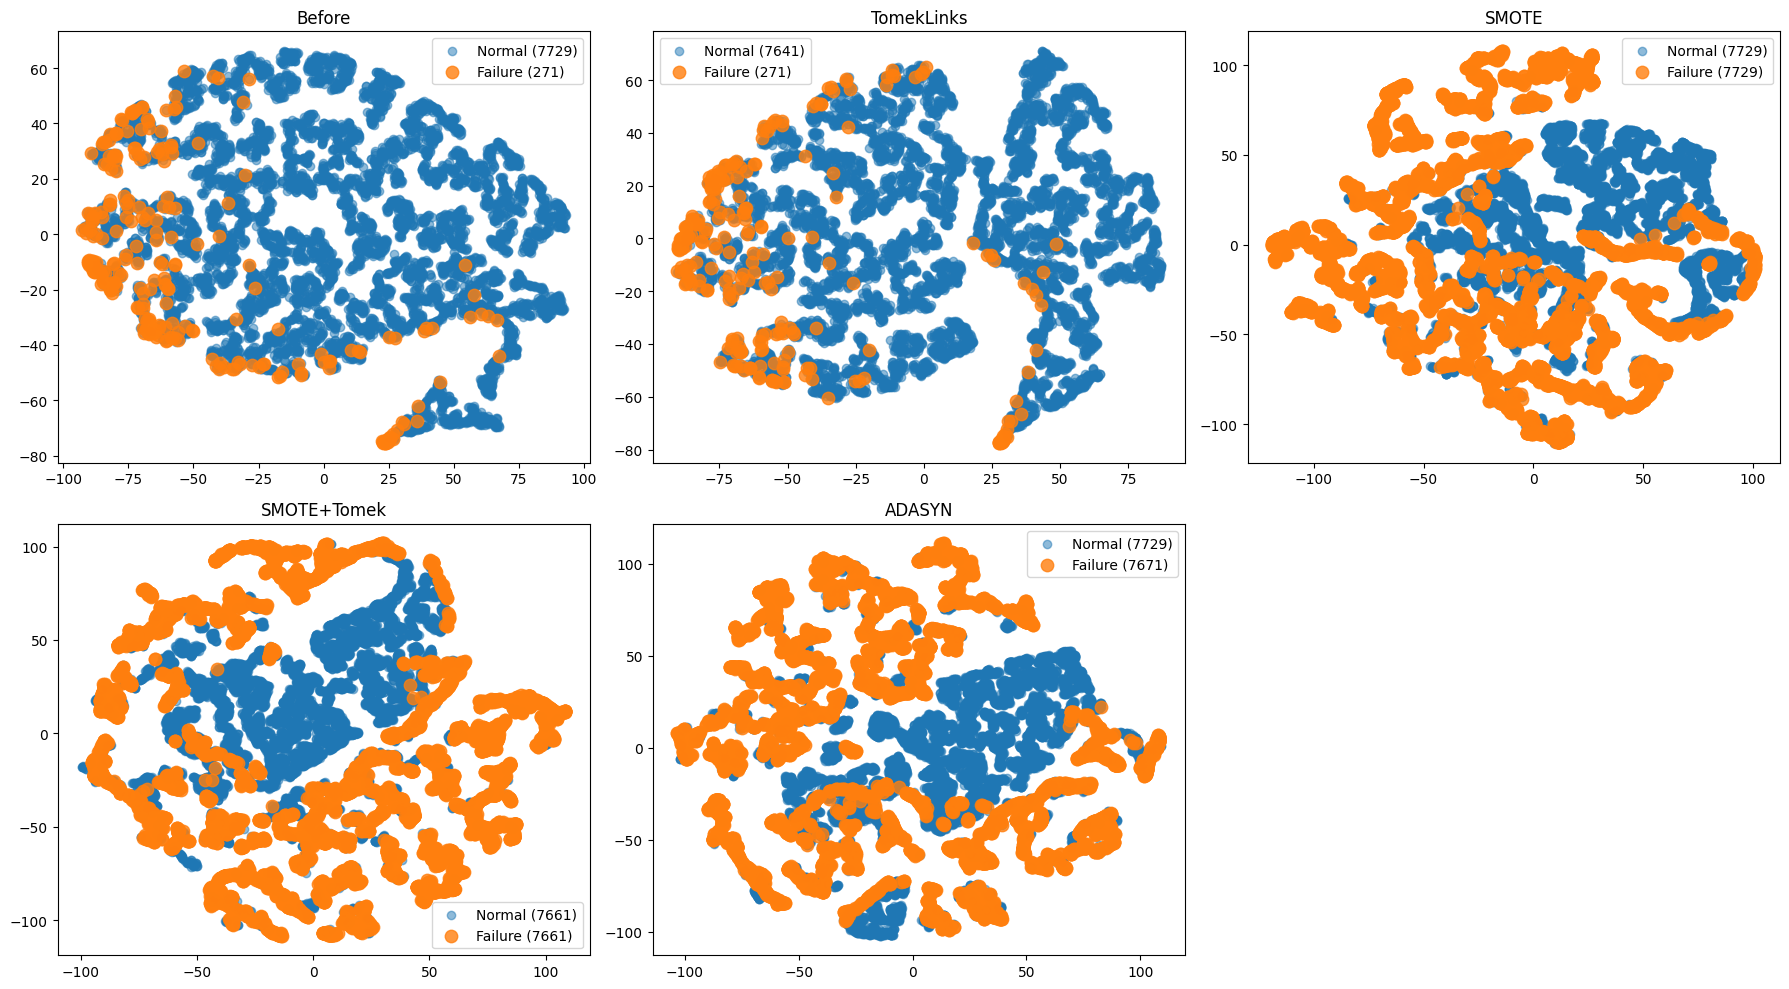

In [15]:
# 방법론별 t-SNE 비교 (Normal vs Failure)
A, B = 0, 1  # Normal, Failure

sampling_datasets = {
    "Before": (X_train, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, init='random', learning_rate='auto', perplexity=30, random_state=42).fit_transform(X_s)
    axes[i].scatter(emb[Y_s.values == A, 0], emb[Y_s.values == A, 1], label=f'Normal ({(Y_s==A).sum()})', alpha=0.5)
    axes[i].scatter(emb[Y_s.values == B, 0], emb[Y_s.values == B, 1], label=f'Failure ({(Y_s==B).sum()})', alpha=0.8, s=80)
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 3-2) Sampling 전후 성능 비교

In [16]:
from xgboost import XGBClassifier

results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():

    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    scale_pos_weight = neg / pos  # 불균형 비율 반영

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test)
    results.append({
        "Method": name,
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 4)
    })

pd.DataFrame(results)

,Method,Precision,Recall,F1-score
0,Before,0.7027,0.7647,0.7324
1,TomekLinks,0.7432,0.8088,0.7746
2,SMOTE,0.5934,0.7941,0.6792
3,SMOTE+Tomek,0.5446,0.8088,0.6509
4,ADASYN,0.5400,0.7941,0.6429


---

## 4) Vibe Coding 실습

**[과제 1]**
지수는 위 t-SNE 시각화 결과(Before / TomekLinks / SMOTE / SMOTE+Tomek / ADASYN)를 보고, Resampling 기법마다 Normal과 Failure 클래스가 어떻게 다르게 분포하는지 궁금해졌습니다.

AI에게 이미지를 보여주며 각 기법의 결과가 어떤 의미를 갖는지 해석을 요청하고 원본 데이터에서 Failure 데이터가 339개(전체의 3.4%)뿐이라는 점을 함께 고려했을 때 이 문제에는 Resampling과 One-Class Learning 중 어떤 접근이 더 적합할지 AI와 논의해 보세요.

#### **[과제 1] t-SNE 해석 및 Resampling vs One-Class Learning 논의**

##### 1. Resampling 기법별 t-SNE 분포 해석

| 기법 | Normal / Failure 분포 특징 | 의미 |
|---|---|---|
| **Before (원본)** | Normal(7,729)이 넓게 퍼져 있고, Failure(271)는 3.4%로 매우 희소하게 점으로 분포. 두 클래스가 **많이 겹침** | 고장 패턴이 정상 공정과 특징 공간에서 크게 분리되지 않음 → 분류 난이도 높음 |
| **TomekLinks** | Normal 일부(88개)만 제거. Failure 수는 동일, 경계에 붙어 있던 Normal이 줄어 **경계가 약간 정리**됨 | 클래스 경계의 모호한 다수 샘플을 제거해 결정 경계를 다듬는 효과. 데이터 손실은 적음 |
| **SMOTE** | Failure가 7,729개로 **급증**, Normal과 Failure 비율 1:1. Failure 점들이 원래 Failure 사이를 **보간해 채워짐** | 소수 클래스 밀도를 인위적으로 높여 모델이 Failure를 더 자주 학습. 겹치는 영역에 **합성 샘플**이 많이 생성됨 |
| **SMOTE+Tomek** | SMOTE 후 Tomek으로 경계 겹침 샘플 정리 → SMOTE보다 **경계가 조금 더 깔끔**, 양 클래스 균형(각 7,658) | 합성 증강 + 경계 정리를 결합. SMOTE 단독보다 노이즈가 줄지만 여전히 합성 데이터 비중이 큼 |
| **ADASYN** | SMOTE와 유사하나 Failure 7,671개로 **경계·어려운 영역에 더 집중** 생성 | 분류가 어려운 Normal-Failure 경계 주변에 가상 샘플을 더 많이 배치 → 경계 학습 강화 의도 |

> **공통 관찰**: 모든 기법에서 Normal과 Failure가 t-SNE 상 **완전히 분리되지 않음**. Oversampling은 Failure 점의 **수·밀도**만 바꿀 뿐, 근본적인 클래스 분리 문제는 해결하지 못함.

##### 2. 성능 관점 (XGBoost, pos_label=Failure)

| Method | Precision | Recall | F1 |
|---|---:|---:|---:|
| Before | 0.7027 | 0.7647 | **0.7324** |
| TomekLinks | 0.7432 | 0.8088 | **0.7746** |
| SMOTE | 0.5684 | 0.7941 | 0.6626 |
| SMOTE+Tomek | 0.5745 | 0.7941 | 0.6667 |
| ADASYN | 0.5400 | 0.7941 | 0.6429 |

- **Undersampling(TomekLinks)**: 합성 데이터 없이 경계만 정리 → Precision·F1 모두 **향상**
- **Oversampling(SMOTE/ADASYN)**: Recall은 유지되지만 Precision **하락** → 겹치는 영역에 만든 합성 Failure가 **오탐(False Positive) 증가**로 이어짐

##### 3. Resampling vs One-Class Learning — 어떤 접근이 더 적합한가?

**데이터 특성**: Failure 339개(3.4%), t-SNE에서 클래스 **중첩 심함** → 소수 클래스 패턴 학습 자체가 어려움.

| 접근 | 적합한 이유 | 한계 |
|---|---|---|
| **Resampling** | Recall 중시, Failure 탐지율을 높이고 싶을 때 | 합성 샘플이 실제 고장 분포와 다를 수 있음 → Precision 하락 (본 실습에서 확인) |
| **One-Class Learning** | 정상(Normal) 데이터가 압도적으로 많고, 고장은 **정상에서 벗어난 이상**으로 볼 때 자연스러움. 테스트 분포(3.4%)와 **학습 가정이 일치** | Failure 유형이 다양하면 단일 정상 모델로 모든 고장을 잡기 어려움 |

**결론 (AI와의 논의 요약)**  
이 문제에는 **One-Class Learning(또는 이상 탐지)을 1순위**로 검토하고, **Resampling은 보조 수단**으로 쓰는 것이 더 적합합니다.

1. Failure 비율 3.4% → 실무 배포 환경과 동일한 불균형 유지가 중요 → One-Class는 정상만 학습해 **실제 분포와 일치**
2. t-SNE에서 클래스가 겹침 → SMOTE/ADASYN 합성 샘플이 **허위 경계**를 만들어 Precision을 떨어뜨림
3. 다만 Recall 극대화가 목표라면 **TomekLinks + class weight** 같은 **가벼운 Resampling**은 F1 개선에 유효 (본 실습: TomekLinks F1 0.7746)

**권장 전략**: One-Class SVM / Isolation Forest / Autoencoder 등으로 **정상 패턴 모델링** + 필요 시 TomekLinks로 경계 정리, 또는 `scale_pos_weight`로 불균형만 반영하는 **하이브리드** 접근.

C:\Users\Admin\AppData\Local\Temp\ipykernel_42452\1583571766.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


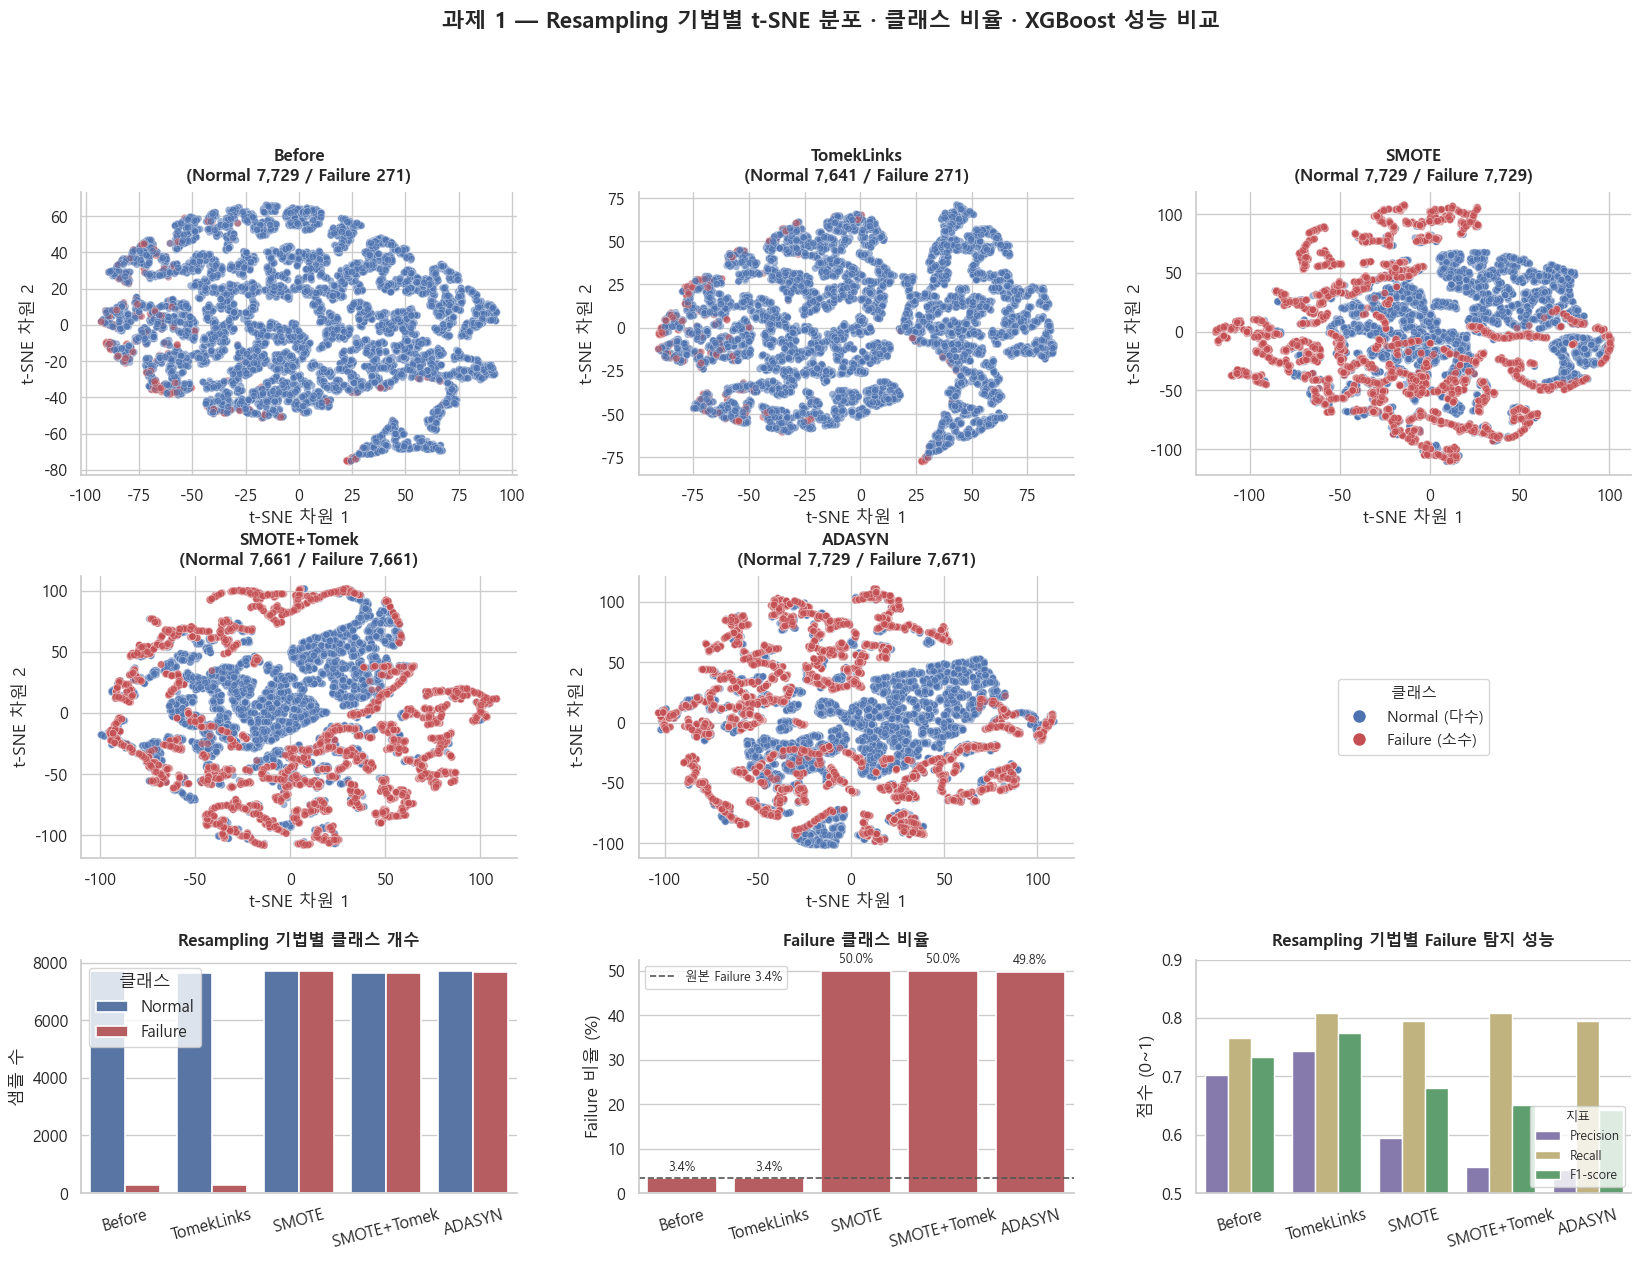


[원본 데이터] Failure 339개 / 전체 10,000개 (3.4%)
 Resampling  Precision  Recall  F1-score
     Before     0.7027  0.7647    0.7324
 TomekLinks     0.7432  0.8088    0.7746
      SMOTE     0.5934  0.7941    0.6792
SMOTE+Tomek     0.5446  0.8088    0.6509
     ADASYN     0.5400  0.7941    0.6429


In [17]:
# ===== [과제 1] seaborn 시각화: t-SNE 분포 비교 + 성능 비교 =====

import matplotlib.font_manager as fm


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    try:
        _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
        _available = {f.name for f in fm.fontManager.ttflist}
        for _font in _korean_fonts:
            if _font in _available:
                plt.rcParams["font.family"] = _font
                break
        else:
            print("[경고] 한글 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
        plt.rcParams["axes.unicode_minus"] = False
    except Exception as e:
        print(f"[경고] 한글 폰트 설정 중 오류 발생: {e}. 기본 폰트를 사용합니다.")
        plt.rcParams["axes.unicode_minus"] = False


# ── 1) t-SNE 좌표 계산 (Resampling 기법별) ──
CLASS_PALETTE = {"Normal (다수)": "#4C72B0", "Failure (소수)": "#C44E52"}

tsne_records = []
for method_name, (X_s, Y_s) in sampling_datasets.items():
    emb = TSNE(
        n_components=2, init="random", learning_rate="auto",
        perplexity=30, random_state=42,
    ).fit_transform(X_s)
    tsne_df = pd.DataFrame({
        "t-SNE 1": emb[:, 0],
        "t-SNE 2": emb[:, 1],
        "클래스": np.where(Y_s == 0, "Normal (다수)", "Failure (소수)"),
        "Resampling": method_name,
    })
    tsne_records.append(tsne_df)

tsne_all = pd.concat(tsne_records, ignore_index=True)
method_order = ["Before", "TomekLinks", "SMOTE", "SMOTE+Tomek", "ADASYN"]

# ── 2) XGBoost 성능 결과 (Cell 41과 동일 로직) ──
from xgboost import XGBClassifier

perf_rows = []
for name, (X_tr, Y_tr) in sampling_datasets.items():
    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    xgb = XGBClassifier(
        n_estimators=100, max_depth=6,
        scale_pos_weight=neg / pos, random_state=42,
    )
    xgb.fit(X_tr, Y_tr)
    pred = xgb.predict(X_test)
    perf_rows.append({
        "Resampling": name,
        "Precision": precision_score(Y_test, pred, pos_label=1),
        "Recall": recall_score(Y_test, pred, pos_label=1),
        "F1-score": f1_score(Y_test, pred, pos_label=1),
    })

perf_df = pd.DataFrame(perf_rows)
perf_long = perf_df.melt(
    id_vars="Resampling", var_name="지표", value_name="점수",
).assign(Resampling=lambda d: pd.Categorical(d["Resampling"], categories=method_order, ordered=True))

# ── 3) seaborn 시각화 ──
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

fig = plt.figure(figsize=(20, 13))
gs = fig.add_gridspec(3, 3, height_ratios=[1.15, 1.15, 0.95], hspace=0.38, wspace=0.28)

# (A) t-SNE 5-panel — Resampling 기법별 클래스 분포
for idx, method in enumerate(method_order):
    row, col = divmod(idx, 3)
    ax = fig.add_subplot(gs[row, col])
    subset = tsne_all[tsne_all["Resampling"] == method]
    n_normal = (subset["클래스"] == "Normal (다수)").sum()
    n_failure = (subset["클래스"] == "Failure (소수)").sum()

    sns.scatterplot(
        data=subset,
        x="t-SNE 1", y="t-SNE 2",
        hue="클래스", palette=CLASS_PALETTE,
        hue_order=["Normal (다수)", "Failure (소수)"],
        alpha=0.55, s=28, edgecolor="white", linewidth=0.3,
        ax=ax, legend=False,
    )
    ax.set_title(
        f"{method}\n(Normal {n_normal:,} / Failure {n_failure:,})",
        fontsize=12, fontweight="bold", pad=8,
    )
    ax.set_xlabel("t-SNE 차원 1")
    ax.set_ylabel("t-SNE 차원 2")
    sns.despine(ax=ax)

# 범례 (공통) — 마지막 패널에서 추출
legend_ax = fig.add_subplot(gs[1, 2])
legend_ax.axis("off")
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C72B0",
               markersize=10, label="Normal (다수)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#C44E52",
               markersize=10, label="Failure (소수)"),
]
legend_ax.legend(handles=legend_handles, loc="center", fontsize=11, frameon=True,
                 title="클래스", title_fontsize=11)

# (B) 클래스 비율 막대그래프
count_rows = []
for method in method_order:
    _, Y_s = sampling_datasets[method]
    count_rows.append({"Resampling": method, "클래스": "Normal", "개수": (Y_s == 0).sum()})
    count_rows.append({"Resampling": method, "클래스": "Failure", "개수": (Y_s == 1).sum()})
count_df = pd.DataFrame(count_rows)
count_df["Resampling"] = pd.Categorical(count_df["Resampling"], categories=method_order, ordered=True)

ax_count = fig.add_subplot(gs[2, 0])
sns.barplot(
    data=count_df, x="Resampling", y="개수", hue="클래스",
    palette={"Normal": "#4C72B0", "Failure": "#C44E52"},
    edgecolor="white", linewidth=1.2, ax=ax_count,
)
ax_count.set_title("Resampling 기법별 클래스 개수", fontsize=12, fontweight="bold", pad=10)
ax_count.set_xlabel("")
ax_count.set_ylabel("샘플 수")
ax_count.tick_params(axis="x", rotation=15)
sns.despine(ax=ax_count)

# (C) Failure 클래스 비율 (%)
ratio_df = count_df.pivot(index="Resampling", columns="클래스", values="개수").reset_index()
ratio_df["Failure 비율(%)"] = (ratio_df["Failure"] / (ratio_df["Normal"] + ratio_df["Failure"]) * 100).round(1)
ratio_df["Resampling"] = pd.Categorical(ratio_df["Resampling"], categories=method_order, ordered=True)

ax_ratio = fig.add_subplot(gs[2, 1])
bar_ratio = sns.barplot(
    data=ratio_df, x="Resampling", y="Failure 비율(%)",
    color="#C44E52", edgecolor="white", linewidth=1.2, ax=ax_ratio,
)
bar_ratio.axhline(3.4, color="#555555", linestyle="--", linewidth=1.2, label="원본 Failure 3.4%")
for container in bar_ratio.containers:
    bar_ratio.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)
ax_ratio.set_title("Failure 클래스 비율", fontsize=12, fontweight="bold", pad=10)
ax_ratio.set_xlabel("")
ax_ratio.set_ylabel("Failure 비율 (%)")
ax_ratio.tick_params(axis="x", rotation=15)
ax_ratio.legend(fontsize=9)
sns.despine(ax=ax_ratio)

# (D) XGBoost 성능 비교 (F1 중심)
ax_perf = fig.add_subplot(gs[2, 2])
sns.barplot(
    data=perf_long, x="Resampling", y="점수", hue="지표",
    palette={"Precision": "#8172B3", "Recall": "#CCB974", "F1-score": "#55A868"},
    edgecolor="white", linewidth=1.0, ax=ax_perf,
)
ax_perf.set_title("Resampling 기법별 Failure 탐지 성능", fontsize=12, fontweight="bold", pad=10)
ax_perf.set_xlabel("")
ax_perf.set_ylabel("점수 (0~1)")
ax_perf.set_ylim(0.5, 0.9)
ax_perf.tick_params(axis="x", rotation=15)
ax_perf.legend(title="지표", fontsize=9, title_fontsize=9, loc="lower right")
sns.despine(ax=ax_perf)

fig.suptitle(
    "과제 1 — Resampling 기법별 t-SNE 분포 · 클래스 비율 · XGBoost 성능 비교",
    fontsize=16, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print("\n[원본 데이터] Failure 339개 / 전체 10,000개 (3.4%)")
print(perf_df.round(4).to_string(index=False))

### [과제 1 추가 최적화] 권장 전략 기반 Optuna 실험

앞선 Discussion의 권장 전략인 **정상 패턴 모델링 + 경계 정리(TomekLinks) + 불균형 반영 하이브리드**를 추가로 검증합니다. 기존 과제 1 결과는 그대로 두고, 아래 새 셀에서 Optuna로 각 방법론의 주요 하이퍼파라미터와 분류 threshold를 함께 최적화합니다.

- Resampling + XGBoost: No Resampling, TomekLinks, SMOTE, SMOTE+Tomek, ADASYN
- 정상 패턴 모델링: One-Class SVM, Isolation Forest
- 평가 기준: validation F1 최적화 후 test set에서 Precision/Recall/F1/PR-AUC 비교
- 시각화: seaborn 기반 성능 비교, confusion matrix, Optuna parameter importance

d:\autornd\SK Autonomous R&D\AutoRnDEnv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna version: 4.9.0
Korean font: Malgun Gothic

[Optuna] No Resampling 최적화 시작


Best trial: 38. Best value: 0.708661: 100%|██████████| 50/50 [00:29<00:00,  1.72it/s]


[Optuna] No Resampling 완료: validation F1=0.7087, test F1=0.7068

[Optuna] TomekLinks 최적화 시작


Best trial: 35. Best value: 0.695035: 100%|██████████| 50/50 [00:35<00:00,  1.40it/s]


...

Best trial: 45. Best value: 0.380488: 100%|██████████| 50/50 [00:20<00:00,  2.42it/s]


[Optuna] One-Class SVM 완료: validation F1=0.3805, test F1=0.3417

[Optuna] Isolation Forest 최적화 시작


Best trial: 12. Best value: 0.309524: 100%|██████████| 50/50 [01:34<00:00,  1.89s/it]


[Optuna] Isolation Forest 완료: validation F1=0.3095, test F1=0.1852


,Precision,Recall,F1-score,Balanced Accuracy,PR-AUC,Method,Family,Best validation F1,Threshold,Train class 0,Train class 1
0,0.7353,0.7353,0.7353,0.8630,0.7614,TomekLinks,Resampling + XGBoost,0.6950,0.7565,7641,271
1,0.7231,0.6912,0.7068,0.8409,0.7383,No Resampling,Resampling + XGBoost,0.7087,0.7757,7729,271
2,0.6769,0.6471,0.6617,0.8181,0.7370,SMOTE,Resampling + XGBoost,0.7273,0.7605,7729,6761
3,0.6667,0.5882,0.6250,0.7889,0.7030,SMOTE+Tomek,Resampling + XGBoost,0.6992,0.7680,7600,5079
4,0.5775,0.6029,0.5899,0.7937,0.6504,ADASYN,Resampling + XGBoost,0.6571,0.6545,7729,3341
5,0.2595,0.5000,0.3417,0.7249,0.3437,One-Class SVM,Normal Pattern Modeling,0.3805,-0.3642,7729,0
6,0.1596,0.2206,0.1852,0.5898,0.2132,Isolation Forest,Normal Pattern Modeling,0.3095,0.5653,7729,0


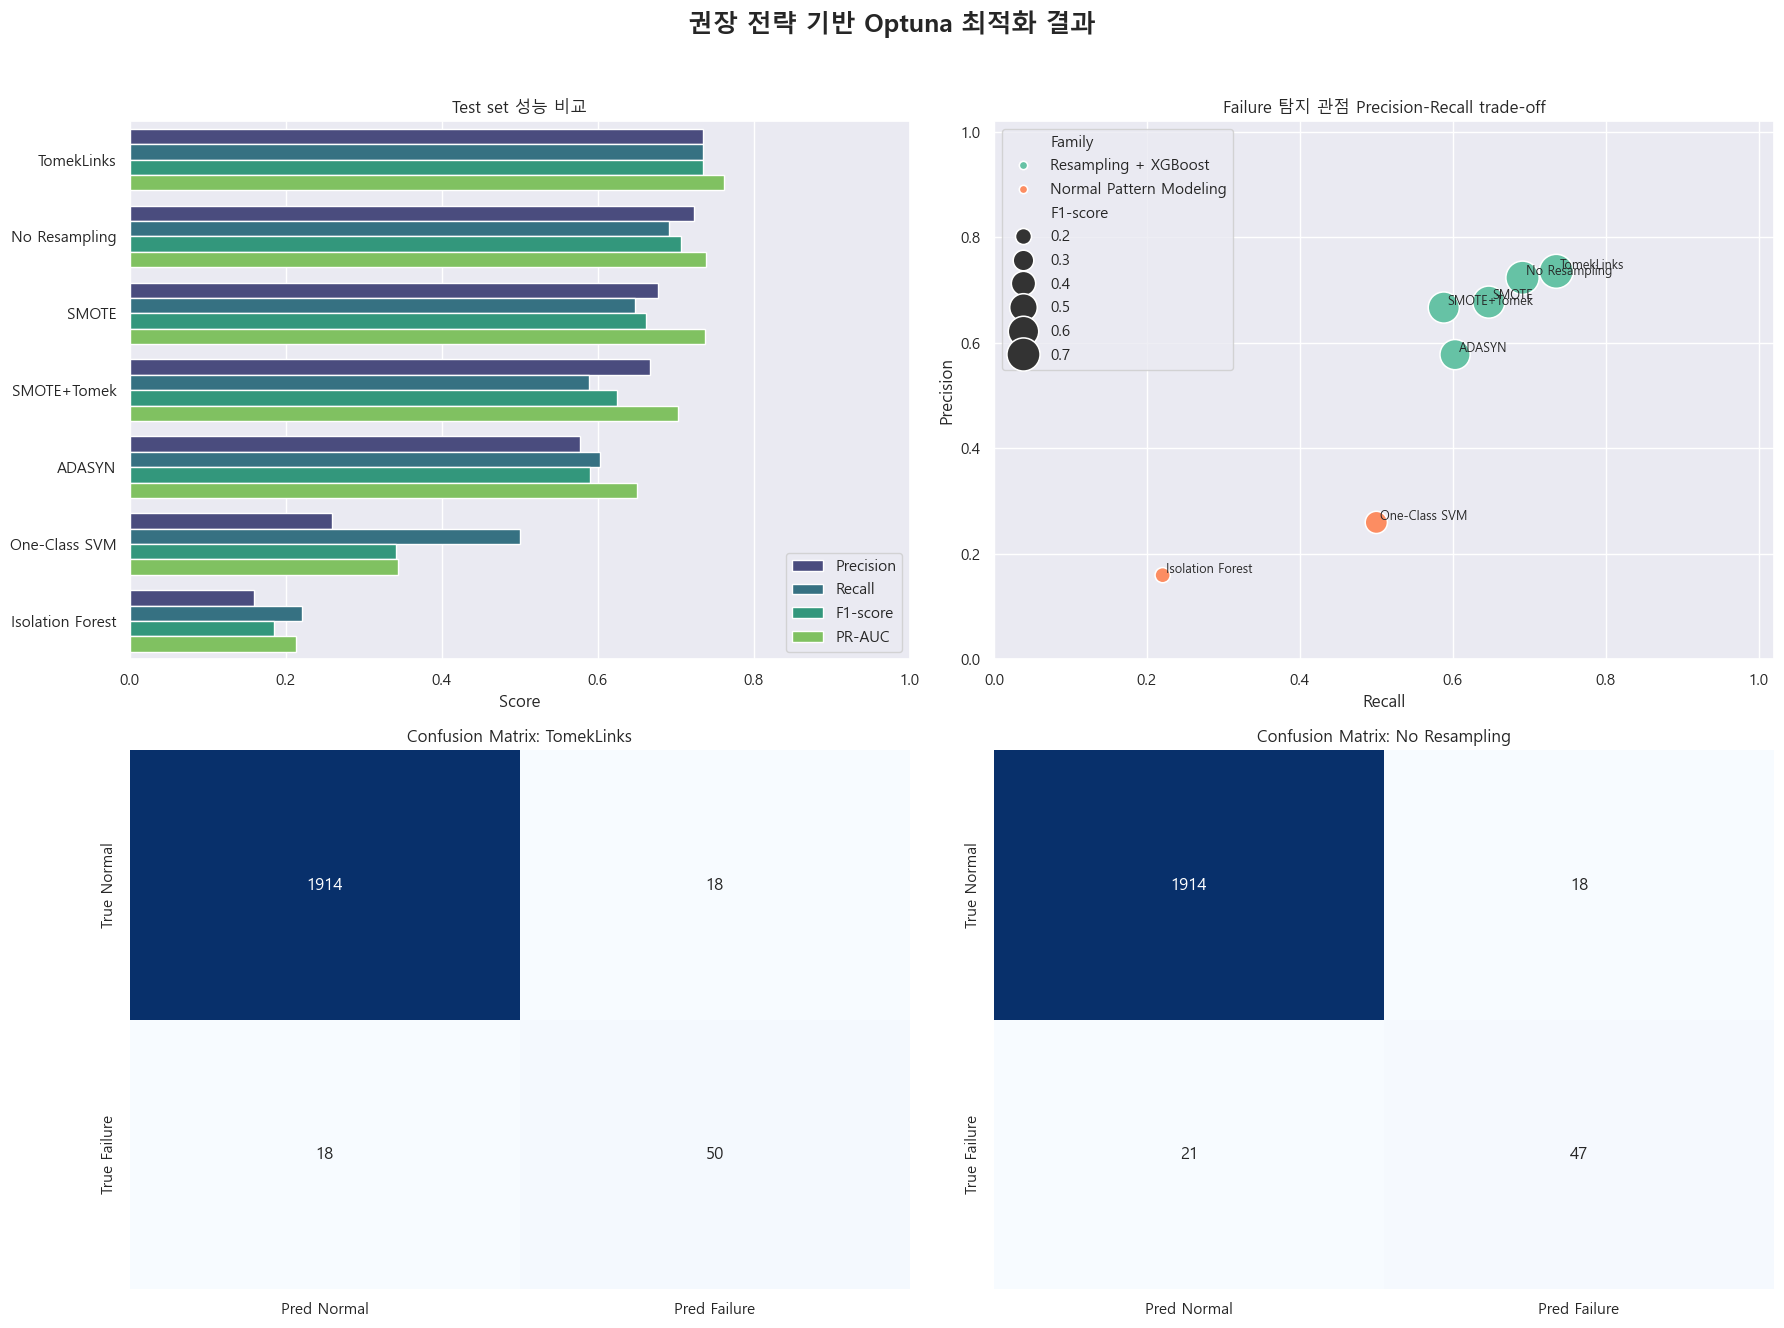

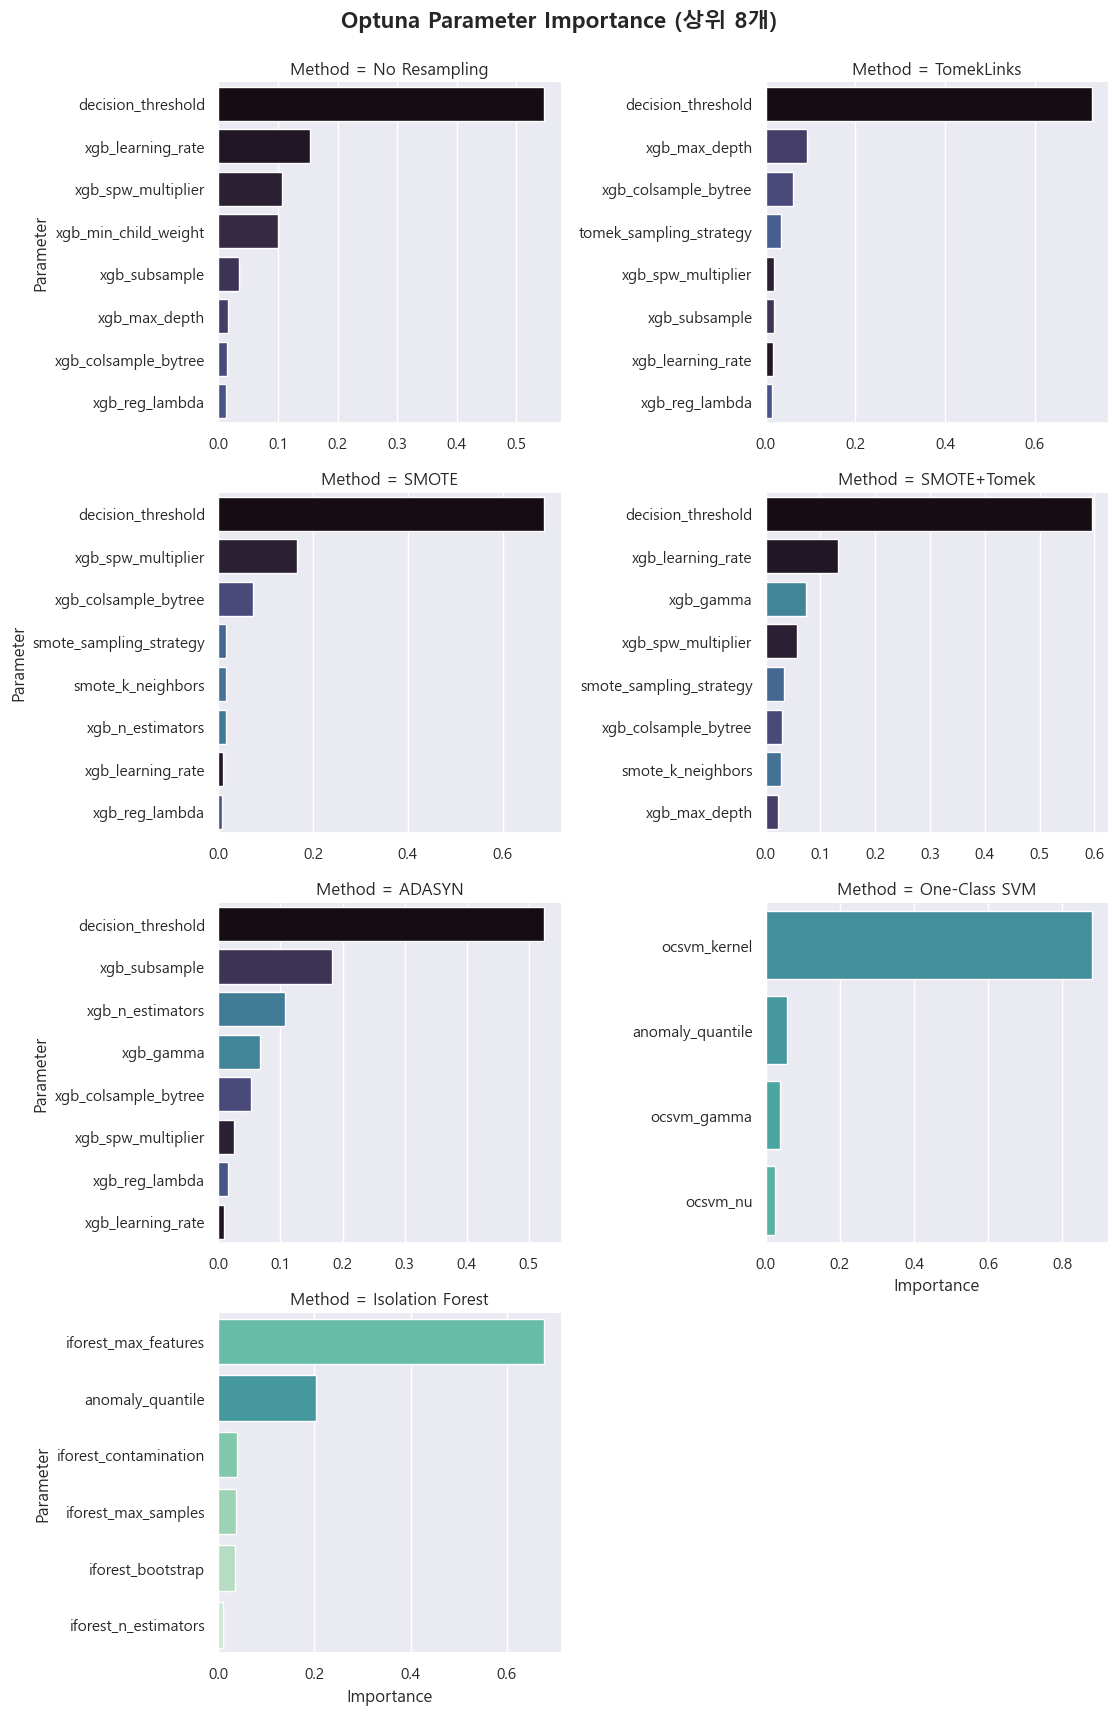


최종 권장: Resampling + XGBoost - TomekLinks
Test F1 기준으로 정렬했으며, 설비 고장 탐지 목적상 Recall과 PR-AUC도 함께 확인하세요.


In [18]:
# ===== [과제 1 추가 최적화] Optuna 기반 권장 전략 검증 =====
# 실행 시간이 부담되면 N_TRIALS 값을 10~20으로 낮춰 먼저 확인한 뒤 늘려주세요.

import sys
import subprocess
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "optuna"])
    import optuna

from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.importance import get_param_importances
from optuna.trial import FixedTrial

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    confusion_matrix,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = 50


def set_korean_seaborn_theme():
    """seaborn 사용 시 한글 폰트 깨짐을 최대한 방지합니다."""
    preferred_fonts = [
        "Malgun Gothic",      # Windows
        "AppleGothic",        # macOS
        "NanumGothic",        # Linux / Colab
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    installed_fonts = {font.name for font in fm.fontManager.ttflist}
    selected_font = next((font for font in preferred_fonts if font in installed_fonts), None)

    sns.set_theme(style="whitegrid", context="notebook")
    if selected_font is not None:
        plt.rcParams["font.family"] = selected_font
        sns.set(font=selected_font)
    else:
        print("[폰트 안내] 한글 폰트를 찾지 못했습니다. 필요 시 Malgun Gothic 또는 NanumGothic 설치 후 재실행하세요.")

    plt.rcParams["axes.unicode_minus"] = False
    return selected_font


selected_font = set_korean_seaborn_theme()
print(f"Optuna version: {optuna.__version__}")
print(f"Korean font: {selected_font if selected_font else 'fallback/default'}")

# Optuna는 test set을 보지 않고, 기존 train set 내부 validation에서만 최적화합니다.
X_fit_base, X_valid, y_fit_base, y_valid = train_test_split(
    X_train,
    Y_train,
    test_size=0.25,
    stratify=Y_train,
    random_state=RANDOM_STATE,
)


def make_study(study_name):
    study = optuna.create_study(
        study_name=study_name,
        direction="maximize",
        sampler=TPESampler(
            seed=RANDOM_STATE,
            multivariate=True,
            group=True,
            constant_liar=True,
        ),
        pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=0),
    )
    if hasattr(study, "set_metric_names"):
        study.set_metric_names(["validation_f1"])
    return study


def suggest_xgb_params(trial, y_resampled):
    neg = int((y_resampled == 0).sum())
    pos = int((y_resampled == 1).sum())
    imbalance_ratio = neg / max(pos, 1)
    return {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 120, 650, step=30),
        "max_depth": trial.suggest_int("xgb_max_depth", 2, 8),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("xgb_subsample", 0.55, 1.00),
        "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.55, 1.00),
        "min_child_weight": trial.suggest_float("xgb_min_child_weight", 1e-2, 20.0, log=True),
        "gamma": trial.suggest_float("xgb_gamma", 0.0, 6.0),
        "reg_alpha": trial.suggest_float("xgb_reg_alpha", 1e-8, 3.0, log=True),
        "reg_lambda": trial.suggest_float("xgb_reg_lambda", 1e-3, 30.0, log=True),
        "scale_pos_weight": imbalance_ratio * trial.suggest_float("xgb_spw_multiplier", 0.35, 3.0, log=True),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }


def build_sampler(method_name, trial):
    if method_name == "No Resampling":
        return None
    if method_name == "TomekLinks":
        return TomekLinks(
            sampling_strategy=trial.suggest_categorical("tomek_sampling_strategy", ["majority", "all"])
        )
    if method_name == "SMOTE":
        return SMOTE(
            sampling_strategy=trial.suggest_float("smote_sampling_strategy", 0.20, 1.00),
            k_neighbors=trial.suggest_int("smote_k_neighbors", 2, 10),
            random_state=RANDOM_STATE,
        )
    if method_name == "SMOTE+Tomek":
        smote = SMOTE(
            sampling_strategy=trial.suggest_float("smote_sampling_strategy", 0.20, 1.00),
            k_neighbors=trial.suggest_int("smote_k_neighbors", 2, 10),
            random_state=RANDOM_STATE,
        )
        tomek = TomekLinks(
            sampling_strategy=trial.suggest_categorical("tomek_sampling_strategy", ["majority", "all"])
        )
        return SMOTETomek(smote=smote, tomek=tomek, random_state=RANDOM_STATE)
    if method_name == "ADASYN":
        return ADASYN(
            sampling_strategy=trial.suggest_float("adasyn_sampling_strategy", 0.20, 1.00),
            n_neighbors=trial.suggest_int("adasyn_n_neighbors", 2, 10),
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unknown method: {method_name}")


def evaluate_predictions(y_true, y_pred, failure_score):
    return {
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, failure_score),
    }


def optimize_xgb_resampling(method_name):
    study = make_study(f"{method_name}_xgb_hybrid")

    def objective(trial):
        try:
            sampler = build_sampler(method_name, trial)
            if sampler is None:
                X_resampled, y_resampled = X_fit_base, y_fit_base
            else:
                X_resampled, y_resampled = sampler.fit_resample(X_fit_base, y_fit_base)

            params = suggest_xgb_params(trial, y_resampled)
            threshold = trial.suggest_float("decision_threshold", 0.05, 0.80)
            model = XGBClassifier(**params)
            model.fit(X_resampled, y_resampled)
            valid_score = model.predict_proba(X_valid)[:, 1]
            valid_pred = (valid_score >= threshold).astype(int)
            score = f1_score(y_valid, valid_pred, pos_label=1, zero_division=0)
            trial.report(score, step=0)
            if trial.should_prune():
                raise optuna.TrialPruned()
            return score
        except Exception:
            raise optuna.TrialPruned()

    study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True, gc_after_trial=True)
    best_trial = FixedTrial(study.best_trial.params)
    best_sampler = build_sampler(method_name, best_trial)

    if best_sampler is None:
        X_resampled, y_resampled = X_train, Y_train
        resampled_counts = Y_train.value_counts().to_dict()
    else:
        X_resampled, y_resampled = best_sampler.fit_resample(X_train, Y_train)
        resampled_counts = pd.Series(y_resampled).value_counts().to_dict()

    params = suggest_xgb_params(best_trial, y_resampled)
    threshold = study.best_trial.params["decision_threshold"]
    final_model = XGBClassifier(**params)
    final_model.fit(X_resampled, y_resampled)
    test_score = final_model.predict_proba(X_test)[:, 1]
    test_pred = (test_score >= threshold).astype(int)

    result = evaluate_predictions(Y_test, test_pred, test_score)
    result.update({
        "Method": method_name,
        "Family": "Resampling + XGBoost",
        "Best validation F1": study.best_value,
        "Threshold": threshold,
        "Train class 0": resampled_counts.get(0, 0),
        "Train class 1": resampled_counts.get(1, 0),
        "Study": study,
        "Pred": test_pred,
        "Score": test_score,
        "Best Params": study.best_trial.params,
    })
    return result


def optimize_oneclass_svm():
    study = make_study("one_class_svm_normal_modeling")
    X_normal_fit = X_fit_base[y_fit_base == 0]

    def objective(trial):
        kernel = trial.suggest_categorical("ocsvm_kernel", ["rbf", "poly", "sigmoid"])
        model = make_pipeline(
            StandardScaler(),
            OneClassSVM(
                kernel=kernel,
                nu=trial.suggest_float("ocsvm_nu", 0.005, 0.20, log=True),
                gamma=trial.suggest_float("ocsvm_gamma", 1e-4, 1.0, log=True),
                degree=trial.suggest_int("ocsvm_degree", 2, 4) if kernel == "poly" else 3,
            ),
        )
        model.fit(X_normal_fit)
        fit_scores = -model.decision_function(X_normal_fit)
        valid_scores = -model.decision_function(X_valid)
        cutoff = np.quantile(fit_scores, trial.suggest_float("anomaly_quantile", 0.90, 0.995))
        valid_pred = (valid_scores >= cutoff).astype(int)
        score = f1_score(y_valid, valid_pred, pos_label=1, zero_division=0)
        trial.report(score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()
        return score

    study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True, gc_after_trial=True)
    p = study.best_trial.params
    kernel = p["ocsvm_kernel"]
    final_model = make_pipeline(
        StandardScaler(),
        OneClassSVM(
            kernel=kernel,
            nu=p["ocsvm_nu"],
            gamma=p["ocsvm_gamma"],
            degree=p.get("ocsvm_degree", 3) if kernel == "poly" else 3,
        ),
    )
    X_normal_train = X_train[Y_train == 0]
    final_model.fit(X_normal_train)
    train_scores = -final_model.decision_function(X_normal_train)
    test_score = -final_model.decision_function(X_test)
    cutoff = np.quantile(train_scores, p["anomaly_quantile"])
    test_pred = (test_score >= cutoff).astype(int)

    result = evaluate_predictions(Y_test, test_pred, test_score)
    result.update({
        "Method": "One-Class SVM",
        "Family": "Normal Pattern Modeling",
        "Best validation F1": study.best_value,
        "Threshold": cutoff,
        "Train class 0": int((Y_train == 0).sum()),
        "Train class 1": 0,
        "Study": study,
        "Pred": test_pred,
        "Score": test_score,
        "Best Params": p,
    })
    return result


def optimize_isolation_forest():
    study = make_study("isolation_forest_normal_modeling")
    X_normal_fit = X_fit_base[y_fit_base == 0]

    def objective(trial):
        model = IsolationForest(
            n_estimators=trial.suggest_int("iforest_n_estimators", 100, 700, step=50),
            max_samples=trial.suggest_float("iforest_max_samples", 0.40, 1.00),
            max_features=trial.suggest_float("iforest_max_features", 0.50, 1.00),
            contamination=trial.suggest_float("iforest_contamination", 0.005, 0.15, log=True),
            bootstrap=trial.suggest_categorical("iforest_bootstrap", [False, True]),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_normal_fit)
        fit_scores = -model.score_samples(X_normal_fit)
        valid_scores = -model.score_samples(X_valid)
        cutoff = np.quantile(fit_scores, trial.suggest_float("anomaly_quantile", 0.90, 0.995))
        valid_pred = (valid_scores >= cutoff).astype(int)
        score = f1_score(y_valid, valid_pred, pos_label=1, zero_division=0)
        trial.report(score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()
        return score

    study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, show_progress_bar=True, gc_after_trial=True)
    p = study.best_trial.params
    final_model = IsolationForest(
        n_estimators=p["iforest_n_estimators"],
        max_samples=p["iforest_max_samples"],
        max_features=p["iforest_max_features"],
        contamination=p["iforest_contamination"],
        bootstrap=p["iforest_bootstrap"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    X_normal_train = X_train[Y_train == 0]
    final_model.fit(X_normal_train)
    train_scores = -final_model.score_samples(X_normal_train)
    test_score = -final_model.score_samples(X_test)
    cutoff = np.quantile(train_scores, p["anomaly_quantile"])
    test_pred = (test_score >= cutoff).astype(int)

    result = evaluate_predictions(Y_test, test_pred, test_score)
    result.update({
        "Method": "Isolation Forest",
        "Family": "Normal Pattern Modeling",
        "Best validation F1": study.best_value,
        "Threshold": cutoff,
        "Train class 0": int((Y_train == 0).sum()),
        "Train class 1": 0,
        "Study": study,
        "Pred": test_pred,
        "Score": test_score,
        "Best Params": p,
    })
    return result


optimization_plan = [
    ("No Resampling", lambda: optimize_xgb_resampling("No Resampling")),
    ("TomekLinks", lambda: optimize_xgb_resampling("TomekLinks")),
    ("SMOTE", lambda: optimize_xgb_resampling("SMOTE")),
    ("SMOTE+Tomek", lambda: optimize_xgb_resampling("SMOTE+Tomek")),
    ("ADASYN", lambda: optimize_xgb_resampling("ADASYN")),
    ("One-Class SVM", optimize_oneclass_svm),
    ("Isolation Forest", optimize_isolation_forest),
]

optimized_results = []
for method_name, runner in optimization_plan:
    print(f"\n[Optuna] {method_name} 최적화 시작")
    try:
        optimized_results.append(runner())
        print(f"[Optuna] {method_name} 완료: validation F1={optimized_results[-1]['Best validation F1']:.4f}, test F1={optimized_results[-1]['F1-score']:.4f}")
    except Exception as exc:
        print(f"[Optuna] {method_name} 실패: {exc}")

result_columns = [
    "Family", "Method", "Precision", "Recall", "F1-score", "Balanced Accuracy", "PR-AUC",
    "Best validation F1", "Threshold", "Train class 0", "Train class 1",
]
optimized_summary = (
    pd.DataFrame([{k: v for k, v in row.items() if k in result_columns} for row in optimized_results])
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)

styled_summary = optimized_summary.style.format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "Balanced Accuracy": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "Best validation F1": "{:.4f}",
    "Threshold": "{:.4f}",
})
display(styled_summary)

# ---- seaborn 시각화 1: 핵심 성능 지표 비교 ----
plot_df = optimized_summary.melt(
    id_vars=["Family", "Method"],
    value_vars=["Precision", "Recall", "F1-score", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("권장 전략 기반 Optuna 최적화 결과", fontsize=18, fontweight="bold", y=1.02)

sns.barplot(
    data=plot_df,
    x="Score",
    y="Method",
    hue="Metric",
    palette="viridis",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Test set 성능 비교")
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_xlabel("Score")
axes[0, 0].set_ylabel("")
axes[0, 0].legend(loc="lower right")

sns.scatterplot(
    data=optimized_summary,
    x="Recall",
    y="Precision",
    size="F1-score",
    hue="Family",
    sizes=(120, 600),
    palette="Set2",
    ax=axes[0, 1],
)
for _, row in optimized_summary.iterrows():
    axes[0, 1].text(row["Recall"] + 0.005, row["Precision"] + 0.005, row["Method"], fontsize=9)
axes[0, 1].set_title("Failure 탐지 관점 Precision-Recall trade-off")
axes[0, 1].set_xlim(0, 1.02)
axes[0, 1].set_ylim(0, 1.02)

best_rows = optimized_summary.head(4)
for ax, method in zip(axes[1], best_rows["Method"].head(2)):
    row = next(item for item in optimized_results if item["Method"] == method)
    cm = confusion_matrix(Y_test, row["Pred"], labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred Normal", "Pred Failure"],
        yticklabels=["True Normal", "True Failure"],
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix: {method}")

plt.tight_layout()
plt.show()

# ---- seaborn 시각화 2: Optuna parameter importance ----
importance_rows = []
for row in optimized_results:
    try:
        importances = get_param_importances(row["Study"])
        for param, importance in list(importances.items())[:8]:
            importance_rows.append({
                "Method": row["Method"],
                "Parameter": param,
                "Importance": importance,
            })
    except Exception:
        continue

importance_df = pd.DataFrame(importance_rows)
if not importance_df.empty:
    g = sns.catplot(
        data=importance_df,
        kind="bar",
        x="Importance",
        y="Parameter",
        col="Method",
        col_wrap=2,
        sharex=False,
        sharey=False,
        height=4.2,
        aspect=1.35,
        palette="mako",
    )
    g.fig.suptitle("Optuna Parameter Importance (상위 8개)", fontsize=16, fontweight="bold", y=1.02)
    g.set_axis_labels("Importance", "Parameter")
    plt.show()

best_method = optimized_summary.iloc[0]["Method"]
best_family = optimized_summary.iloc[0]["Family"]
print(f"\n최종 권장: {best_family} - {best_method}")
print("Test F1 기준으로 정렬했으며, 설비 고장 탐지 목적상 Recall과 PR-AUC도 함께 확인하세요.")

### [과제 1 추가 최적화] GPSampler 기반 Pareto Frontier 탐색

TPE 단일목표 최적화 대신 Optuna 최신 `GPSampler`를 사용하여 **F1-score, Recall, Precision**을 동시에 최대화하는 다목표 최적화를 수행합니다. 각 trial은 resampling 방법론과 XGBoost 하이퍼파라미터, decision threshold를 함께 탐색하며, 최종적으로 Pareto frontier 후보를 test set에서 재평가합니다.

Optuna version: 4.9.0
Sampler: GPSampler
Korean font: Malgun Gothic


 20%|██        | 12/60 [00:14<00:36,  1.30it/s]

[W 2026-07-06 15:45:27,956] The parameter `tomek_sampling_strategy` in Trial#12 is sampled independently using `RandomSampler` instead of `GPSampler`, potentially degrading the optimization performance. This fallback happened because dynamic search space is not supported by GPSampler. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `GPSampler` if this independent sampling is intended behavior.


 27%|██▋       | 16/60 [00:25<01:57,  2.68s/it]

[W 2026-07-06 15:45:39,200] The parameter `tomek_sampling_strategy` in Trial#16 is sampled independently using `RandomSampler` instead of `GPSampler`, potentially degrading the optimization performance. This fallback happened because dynamic search space is not supported by GPSampler. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `GPSampler` if this independent sampling is intended behavior.


...

100%|██████████| 60/60 [03:01<00:00,  3.02s/it]

Completed trials: 60
Pareto frontier trials: 16


,Trial,Method,Validation F1-score,Validation Recall,Validation Precision,Threshold,Pareto Frontier
0,41,No Resampling,0.7040,0.6471,0.7719,0.8500,True
1,42,No Resampling,0.6957,0.5882,0.8511,0.8500,True
2,13,No Resampling,0.6761,0.7059,0.6486,0.8500,True
3,39,No Resampling,0.6714,0.6912,0.6528,0.8500,True
4,52,No Resampling,0.6712,0.7206,0.6282,0.4472,True
5,54,No Resampling,0.6618,0.6618,0.6618,0.6915,True
6,20,No Resampling,0.6289,0.7353,0.5495,0.8500,True
7,0,TomekLinks,0.6190,0.7647,0.5200,0.4603,True
8,10,No Resampling,0.6182,0.7500,0.5258,0.7656,True
9,49,No Resampling,0.5759,0.8088,0.4472,0.3130,True


,F1-score,Recall,Precision,Balanced Accuracy,PR-AUC,Trial,Method,Threshold,Train class 0,Train class 1
0,0.7794,0.7794,0.7794,0.8858,0.8361,54,No Resampling,0.6915,7729,271
1,0.7642,0.6912,0.8545,0.8435,0.8355,42,No Resampling,0.8500,7729,271
2,0.7626,0.7794,0.7465,0.8850,0.8032,39,No Resampling,0.8500,7729,271
3,0.7600,0.8382,0.6951,0.9126,0.8065,0,TomekLinks,0.4603,7641,271
4,0.7576,0.7353,0.7812,0.8640,0.8286,41,No Resampling,0.8500,7729,271
5,0.7483,0.8088,0.6962,0.8982,0.8489,52,No Resampling,0.4472,7729,271
6,0.7361,0.7794,0.6974,0.8838,0.8126,13,No Resampling,0.8500,7729,271
7,0.6914,0.8235,0.5957,0.9019,0.7940,10,No Resampling,0.7656,7729,271
8,0.6835,0.7941,0.6000,0.8877,0.7960,20,No Resampling,0.8500,7729,271
9,0.6477,0.8382,0.5278,0.9059,0.8335,49,No Resampling,0.3130,7729,271


ValueError: value_name (Score) cannot match an element in the DataFrame columns.

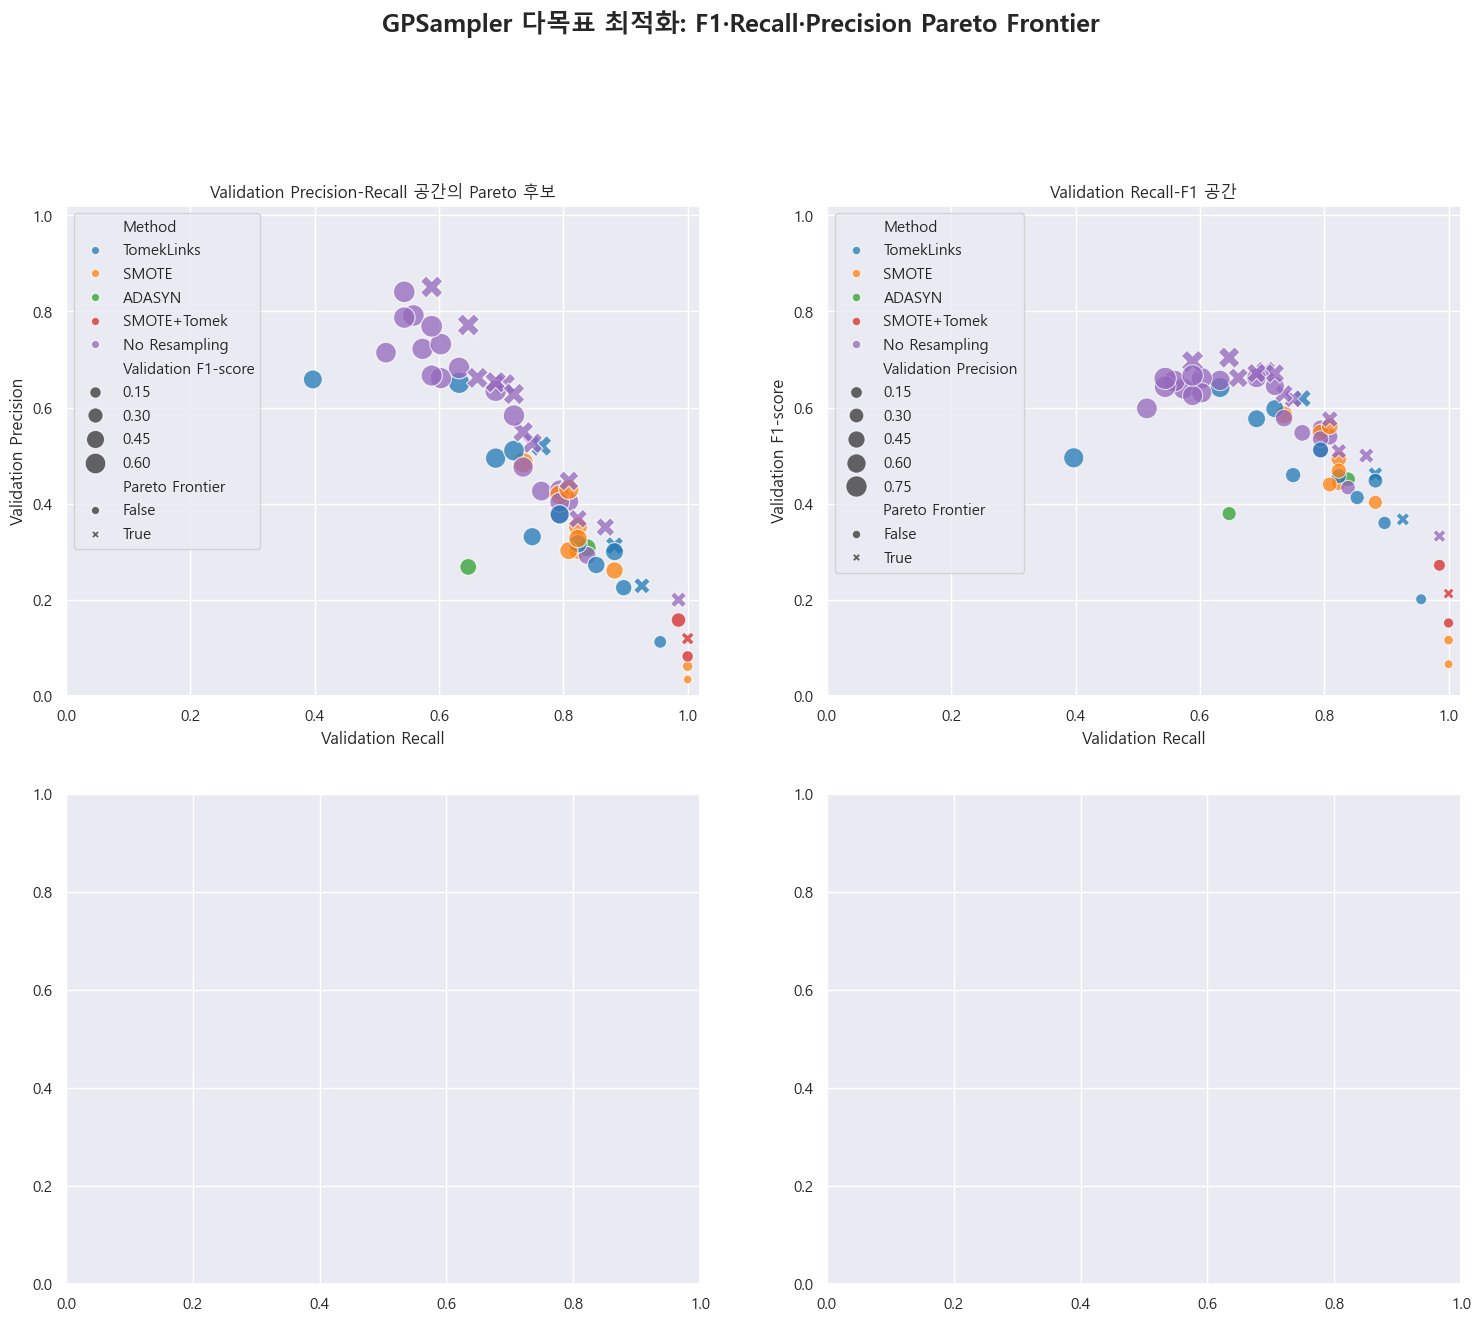

In [19]:
# ===== [과제 1 추가 최적화] GPSampler 기반 F1·Recall·Precision Pareto Frontier =====
# GPSampler는 Gaussian Process 기반 sampler입니다. 실행 시간이 부담되면 N_GPS_TRIALS를 낮춰 먼저 확인하세요.

import sys
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "optuna"])
    import optuna

from optuna.samplers import GPSampler, RandomSampler
from optuna.trial import TrialState, FixedTrial

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    average_precision_score,
    confusion_matrix,
)
from xgboost import XGBClassifier
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_GPS_TRIALS = 60


def set_korean_seaborn_theme():
    preferred_fonts = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
    installed_fonts = {font.name for font in fm.fontManager.ttflist}
    selected_font = next((font for font in preferred_fonts if font in installed_fonts), None)

    sns.set_theme(style="whitegrid", context="notebook")
    if selected_font is not None:
        plt.rcParams["font.family"] = selected_font
        sns.set(font=selected_font)
    else:
        print("[폰트 안내] 한글 폰트를 찾지 못했습니다. 필요 시 Malgun Gothic 또는 NanumGothic 설치 후 재실행하세요.")

    plt.rcParams["axes.unicode_minus"] = False
    return selected_font


selected_font = set_korean_seaborn_theme()
print(f"Optuna version: {optuna.__version__}")
print(f"Sampler: GPSampler")
print(f"Korean font: {selected_font if selected_font else 'fallback/default'}")

X_fit_base, X_valid, y_fit_base, y_valid = train_test_split(
    X_train,
    Y_train,
    test_size=0.25,
    stratify=Y_train,
    random_state=RANDOM_STATE,
)


def build_pareto_sampler(method_name, trial):
    if method_name == "No Resampling":
        return None
    if method_name == "TomekLinks":
        return TomekLinks(
            sampling_strategy=trial.suggest_categorical("tomek_sampling_strategy", ["majority", "all"])
        )
    if method_name == "SMOTE":
        return SMOTE(
            sampling_strategy=trial.suggest_float("smote_sampling_strategy", 0.20, 1.00),
            k_neighbors=trial.suggest_int("smote_k_neighbors", 2, 10),
            random_state=RANDOM_STATE,
        )
    if method_name == "SMOTE+Tomek":
        smote = SMOTE(
            sampling_strategy=trial.suggest_float("smote_sampling_strategy", 0.20, 1.00),
            k_neighbors=trial.suggest_int("smote_k_neighbors", 2, 10),
            random_state=RANDOM_STATE,
        )
        tomek = TomekLinks(
            sampling_strategy=trial.suggest_categorical("tomek_sampling_strategy", ["majority", "all"])
        )
        return SMOTETomek(smote=smote, tomek=tomek, random_state=RANDOM_STATE)
    if method_name == "ADASYN":
        return ADASYN(
            sampling_strategy=trial.suggest_float("adasyn_sampling_strategy", 0.20, 1.00),
            n_neighbors=trial.suggest_int("adasyn_n_neighbors", 2, 10),
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unknown method: {method_name}")


def suggest_pareto_xgb_params(trial, y_resampled):
    neg = int((y_resampled == 0).sum())
    pos = int((y_resampled == 1).sum())
    imbalance_ratio = neg / max(pos, 1)
    return {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 120, 650, step=30),
        "max_depth": trial.suggest_int("xgb_max_depth", 2, 8),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("xgb_subsample", 0.55, 1.00),
        "colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.55, 1.00),
        "min_child_weight": trial.suggest_float("xgb_min_child_weight", 1e-2, 20.0, log=True),
        "gamma": trial.suggest_float("xgb_gamma", 0.0, 6.0),
        "reg_alpha": trial.suggest_float("xgb_reg_alpha", 1e-8, 3.0, log=True),
        "reg_lambda": trial.suggest_float("xgb_reg_lambda", 1e-3, 30.0, log=True),
        "scale_pos_weight": imbalance_ratio * trial.suggest_float("xgb_spw_multiplier", 0.35, 3.0, log=True),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0,
    }


def evaluate_pareto_predictions(y_true, y_pred, failure_score):
    return {
        "F1-score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "PR-AUC": average_precision_score(y_true, failure_score),
    }


def is_pareto_efficient(values):
    values = np.asarray(values)
    efficient = np.ones(values.shape[0], dtype=bool)
    for i, candidate in enumerate(values):
        if efficient[i]:
            dominates = np.all(values >= candidate, axis=1) & np.any(values > candidate, axis=1)
            dominates[i] = False
            if dominates.any():
                efficient[i] = False
    return efficient


methods = ["No Resampling", "TomekLinks", "SMOTE", "SMOTE+Tomek", "ADASYN"]
N_GPS_TRIALS_PER_METHOD = max(12, N_GPS_TRIALS // len(methods))

# GPSampler는 dynamic search space를 완전히 지원하지 않으므로, 방법론별로 별도 study를 만들어
# 각 study 내부 search space를 고정한 뒤 전체 trial을 합쳐 Pareto frontier를 계산합니다.
pareto_studies = {}
trial_rows = []
global_trial_id = 0

for method_name in methods:
    gps_sampler = GPSampler(
        seed=RANDOM_STATE,
        independent_sampler=RandomSampler(seed=RANDOM_STATE),
        n_startup_trials=min(8, N_GPS_TRIALS_PER_METHOD),
        deterministic_objective=True,
        warn_independent_sampling=False,
    )
    study = optuna.create_study(
        directions=["maximize", "maximize", "maximize"],
        sampler=gps_sampler,
        study_name=f"gps_f1_recall_precision_pareto_{method_name}",
    )
    if hasattr(study, "set_metric_names"):
        study.set_metric_names(["F1-score", "Recall", "Precision"])

    def gps_objective(trial, fixed_method=method_name):
        try:
            sampler = build_pareto_sampler(fixed_method, trial)
            if sampler is None:
                X_resampled, y_resampled = X_fit_base, y_fit_base
            else:
                X_resampled, y_resampled = sampler.fit_resample(X_fit_base, y_fit_base)

            params = suggest_pareto_xgb_params(trial, y_resampled)
            threshold = trial.suggest_float("decision_threshold", 0.03, 0.85)
            model = XGBClassifier(**params)
            model.fit(X_resampled, y_resampled)

            valid_score = model.predict_proba(X_valid)[:, 1]
            valid_pred = (valid_score >= threshold).astype(int)
            metrics = evaluate_pareto_predictions(y_valid, valid_pred, valid_score)
            return metrics["F1-score"], metrics["Recall"], metrics["Precision"]
        except Exception:
            return 0.0, 0.0, 0.0

    print(f"[GPSampler] {method_name} 다목표 최적화 시작 ({N_GPS_TRIALS_PER_METHOD} trials)")
    study.optimize(gps_objective, n_trials=N_GPS_TRIALS_PER_METHOD, n_jobs=1, show_progress_bar=True, gc_after_trial=True)
    pareto_studies[method_name] = study

    completed_trials = [trial for trial in study.trials if trial.state == TrialState.COMPLETE and trial.values is not None]
    for trial in completed_trials:
        trial_rows.append({
            "Trial": global_trial_id,
            "Study Trial": trial.number,
            "Method": method_name,
            "Validation F1-score": trial.values[0],
            "Validation Recall": trial.values[1],
            "Validation Precision": trial.values[2],
            "Threshold": trial.params.get("decision_threshold", np.nan),
            "Params": trial.params,
        })
        global_trial_id += 1

trial_df = pd.DataFrame(trial_rows)
metric_cols = ["Validation F1-score", "Validation Recall", "Validation Precision"]
trial_df["Pareto Frontier"] = is_pareto_efficient(trial_df[metric_cols].to_numpy()) if not trial_df.empty else []

pareto_validation_df = (
    trial_df[trial_df["Pareto Frontier"]]
    .sort_values(["Validation F1-score", "Validation Recall", "Validation Precision"], ascending=False)
    .reset_index(drop=True)
)

print(f"Completed trials: {len(completed_trials)}")
print(f"Pareto frontier trials: {len(pareto_validation_df)}")
display(
    pareto_validation_df.drop(columns=["Params"]).style.format({
        "Validation F1-score": "{:.4f}",
        "Validation Recall": "{:.4f}",
        "Validation Precision": "{:.4f}",
        "Threshold": "{:.4f}",
    })
)

# Pareto 후보를 전체 train set으로 재학습한 뒤 test set에서 다시 평가합니다.
test_rows = []
for _, pareto_row in pareto_validation_df.iterrows():
    fixed_trial = FixedTrial(pareto_row["Params"])
    method_name = pareto_row["Method"]
    sampler = build_pareto_sampler(method_name, fixed_trial)
    if sampler is None:
        X_resampled, y_resampled = X_train, Y_train
    else:
        X_resampled, y_resampled = sampler.fit_resample(X_train, Y_train)

    params = suggest_pareto_xgb_params(fixed_trial, y_resampled)
    threshold = pareto_row["Threshold"]
    final_model = XGBClassifier(**params)
    final_model.fit(X_resampled, y_resampled)
    test_score = final_model.predict_proba(X_test)[:, 1]
    test_pred = (test_score >= threshold).astype(int)
    test_metrics = evaluate_pareto_predictions(Y_test, test_pred, test_score)
    test_metrics.update({
        "Trial": int(pareto_row["Trial"]),
        "Method": method_name,
        "Threshold": threshold,
        "Train class 0": int(pd.Series(y_resampled).value_counts().get(0, 0)),
        "Train class 1": int(pd.Series(y_resampled).value_counts().get(1, 0)),
        "Pred": test_pred,
        "Score": test_score,
        "Params": pareto_row["Params"],
    })
    test_rows.append(test_metrics)

gps_pareto_test_df = (
    pd.DataFrame(test_rows)
    .sort_values(["F1-score", "Recall", "Precision"], ascending=False)
    .reset_index(drop=True)
)

display(
    gps_pareto_test_df.drop(columns=["Pred", "Score", "Params"]).style.format({
        "F1-score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Threshold": "{:.4f}",
    })
)

# ---- seaborn 시각화: validation trial 전체와 Pareto frontier ----
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("GPSampler 다목표 최적화: F1·Recall·Precision Pareto Frontier", fontsize=18, fontweight="bold", y=1.02)

sns.scatterplot(
    data=trial_df,
    x="Validation Recall",
    y="Validation Precision",
    hue="Method",
    style="Pareto Frontier",
    size="Validation F1-score",
    sizes=(40, 260),
    alpha=0.75,
    palette="tab10",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Validation Precision-Recall 공간의 Pareto 후보")
axes[0, 0].set_xlim(0, 1.02)
axes[0, 0].set_ylim(0, 1.02)

sns.scatterplot(
    data=trial_df,
    x="Validation Recall",
    y="Validation F1-score",
    hue="Method",
    style="Pareto Frontier",
    size="Validation Precision",
    sizes=(40, 260),
    alpha=0.75,
    palette="tab10",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Validation Recall-F1 공간")
axes[0, 1].set_xlim(0, 1.02)
axes[0, 1].set_ylim(0, 1.02)

pareto_plot_df = gps_pareto_test_df.melt(
    id_vars=["Trial", "Method"],
    value_vars=["F1-score", "Recall", "Precision", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(
    data=pareto_plot_df,
    x="Score",
    y="Trial",
    hue="Metric",
    orient="h",
    palette="viridis",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Pareto 후보의 Test set 성능")
axes[1, 0].set_xlim(0, 1.02)
axes[1, 0].set_ylabel("Trial")

if not gps_pareto_test_df.empty:
    best_trial_row = gps_pareto_test_df.iloc[0]
    cm = confusion_matrix(Y_test, best_trial_row["Pred"], labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred Normal", "Pred Failure"],
        yticklabels=["True Normal", "True Failure"],
        ax=axes[1, 1],
    )
    axes[1, 1].set_title(f"Best Test F1 Pareto 후보: Trial {int(best_trial_row['Trial'])} / {best_trial_row['Method']}")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# 3개 목적함수의 Pareto frontier를 3D로도 확인합니다.
if not trial_df.empty:
    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")
    non_pareto = trial_df[~trial_df["Pareto Frontier"]]
    pareto_only = trial_df[trial_df["Pareto Frontier"]]
    ax.scatter(
        non_pareto["Validation Recall"],
        non_pareto["Validation Precision"],
        non_pareto["Validation F1-score"],
        s=35,
        alpha=0.35,
        label="Other trials",
    )
    ax.scatter(
        pareto_only["Validation Recall"],
        pareto_only["Validation Precision"],
        pareto_only["Validation F1-score"],
        s=120,
        color="crimson",
        label="Pareto frontier",
    )
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_zlabel("F1-score")
    ax.set_title("3D Pareto Frontier: Recall · Precision · F1")
    ax.legend()
    plt.show()

print("\nGPSampler Pareto frontier 탐색 완료")
print("검증 Pareto 후보 중 test F1 기준 최상위 후보:")
if not gps_pareto_test_df.empty:
    display(gps_pareto_test_df.drop(columns=["Pred", "Score", "Params"]).head(1))